# Extract Real Quantum-State Amplitudes Using Quantum Tomography

This notebook reconstructs the density matrix of a quantum state using full Pauli-basis quantum state tomography, then extracts real amplitudes with signs.

We assume the input circuit prepares

$$
|\psi\rangle = U|0^N\rangle = \sum_x a_x |x\rangle,
$$

where all amplitudes are real:

$$
a_x \in \mathbb{R}.
$$

The global sign is fixed by assuming the first amplitude is positive:

$$
a_{00\cdots 0} > 0.
$$

After tomography, we reconstruct

$$
\rho = |\psi\rangle\langle\psi|.
$$

For a real pure state,

$$
\rho_{xy} = a_x a_y.
$$

Therefore,

$$
a_{00\cdots 0} = \sqrt{\rho_{00,00}},
$$

and

$$
a_x =
\frac{\mathrm{Re}(\rho_{0x})}{a_{00\cdots 0}}.
$$

## Scalability note

The code is written for arbitrary \(N\), but full tomography is exponentially expensive.

The number of measurement settings is

$$
3^N,
$$

and the density matrix has size

$$
2^N \times 2^N.
$$

So this is general in code, but practical only for small \(N\).

In [1]:
# If needed, install dependencies first.
# In a local Jupyter notebook, uncomment this cell:
#
# !pip install qiskit qiskit-aer numpy pandas

In [2]:
import itertools
import numpy as np
import pandas as pd

from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator
from qiskit.quantum_info import Statevector

## 1. Helper functions for bitstrings and Pauli strings

In [3]:
def all_bitstrings(n):
    """
    Return all computational-basis bitstrings in Qiskit convention.

    Example for n=3:
        "000", "001", "010", ..., "111"
    """
    return [format(i, f"0{n}b") for i in range(2**n)]


def all_pauli_strings(n):
    """
    Generate all length-n Pauli strings over {I, X, Y, Z}.

    The string order follows Qiskit's displayed bitstring order:
        q_{n-1} ... q_1 q_0

    Example for n=3:
        "IXZ" means I on q2, X on q1, Z on q0.
    """
    return ["".join(p) for p in itertools.product("IXYZ", repeat=n)]


def unique_tomography_bases(n):
    """
    Full tomography measurement bases: all strings in {X, Y, Z}^n.
    Number of settings = 3^n.
    """
    return ["".join(b) for b in itertools.product("XYZ", repeat=n)]


def pauli_to_measurement_basis(pauli_string):
    """
    Convert a Pauli string into a compatible measurement basis.

    If a Pauli character is I, we choose Z measurement for that qubit.
    """
    basis = []

    for p in pauli_string:
        if p == "I":
            basis.append("Z")
        else:
            basis.append(p)

    return "".join(basis)

## 2. Tomography measurement circuits

To measure in \(X\), \(Y\), or \(Z\), rotate before computational-basis measurement.

| Desired basis | Rotation before Z measurement |
|---|---|
| \(Z\) | none |
| \(X\) | \(H\) |
| \(Y\) | \(S^\dagger\), then \(H\) |

In [4]:
def add_basis_rotation(qc, basis):
    """
    Add rotations so that Z measurement corresponds to the requested basis.

    The basis string is ordered as:
        q_{n-1} ... q_1 q_0

    Qiskit qubit indices are:
        q_0, q_1, ..., q_{n-1}

    Therefore basis[i] corresponds to qubit n-1-i.
    """
    n = len(basis)

    for i, b in enumerate(basis):
        qubit = n - 1 - i

        if b == "X":
            qc.h(qubit)

        elif b == "Y":
            qc.sdg(qubit)
            qc.h(qubit)

        elif b == "Z":
            pass

        else:
            raise ValueError(f"Unknown basis character: {b}")


def make_tomography_circuit(state_circuit, basis):
    """
    Create one tomography circuit:
    1. prepare |psi>
    2. rotate into the requested measurement basis
    3. measure all qubits
    """
    n = state_circuit.num_qubits

    U = state_circuit.copy()
    U.remove_final_measurements(inplace=True)

    qc = QuantumCircuit(n, n)
    qc.compose(U, range(n), inplace=True)

    add_basis_rotation(qc, basis)

    qc.measure(range(n), range(n))

    return qc

## 3. Estimate Pauli expectation values from counts

For a Pauli string \(P\),

$$
\langle P\rangle =
\sum_b p(b)\lambda_P(b),
$$

where \(\lambda_P(b)=\pm 1\) is the eigenvalue associated with a measured bitstring.

In [5]:
def pauli_eigenvalue_from_bitstring(pauli_string, bitstring):
    """
    Compute the eigenvalue +/-1 for a Pauli string from a measured bitstring.

    pauli_string and bitstring are both ordered as:
        q_{n-1} ... q_1 q_0

    For I, ignore that qubit.
    For X, Y, or Z:
        measured bit 0 -> eigenvalue +1
        measured bit 1 -> eigenvalue -1
    """
    eig = 1

    for p, bit in zip(pauli_string, bitstring):
        if p == "I":
            continue

        if bit == "0":
            eig *= +1
        elif bit == "1":
            eig *= -1
        else:
            raise ValueError(f"Invalid bit: {bit}")

    return eig


def estimate_pauli_expectation(pauli_string, counts):
    """
    Estimate <P> from counts obtained in a compatible measurement basis.
    """
    shots = sum(counts.values())
    expval = 0.0

    for bitstring, count in counts.items():
        eig = pauli_eigenvalue_from_bitstring(pauli_string, bitstring)
        expval += eig * count / shots

    return expval

## 4. Pauli matrices and density-matrix reconstruction

The full density matrix is reconstructed using

$$
\rho =
\frac{1}{2^N}
\sum_{P\in\{I,X,Y,Z\}^N}
\langle P\rangle P.
$$

In [6]:
def single_pauli_matrix(p):
    """
    Return the 2x2 matrix for I, X, Y, or Z.
    """
    if p == "I":
        return np.array([[1, 0], [0, 1]], dtype=complex)

    if p == "X":
        return np.array([[0, 1], [1, 0]], dtype=complex)

    if p == "Y":
        return np.array([[0, -1j], [1j, 0]], dtype=complex)

    if p == "Z":
        return np.array([[1, 0], [0, -1]], dtype=complex)

    raise ValueError(f"Unknown Pauli: {p}")


def pauli_matrix(pauli_string):
    """
    Build the full matrix for a Pauli string.

    The string is ordered as:
        q_{n-1} ... q_1 q_0

    This matches the computational-basis ordering:
        |000>, |001>, |010>, ..., |111>
    """
    mats = [single_pauli_matrix(p) for p in pauli_string]

    result = mats[0]
    for mat in mats[1:]:
        result = np.kron(result, mat)

    return result

## 5. Optional physical projection

Linear-inversion tomography can produce tiny negative eigenvalues due to finite-shot noise.

The helper below projects the result to a Hermitian, positive-semidefinite, trace-one density matrix.

This is not full maximum-likelihood tomography, but it is useful for stabilizing noisy results.

In [7]:
def project_to_physical_density_matrix(rho):
    """
    Simple projection to a physical density matrix.

    Steps:
    1. Hermitize rho.
    2. Diagonalize.
    3. Clip negative eigenvalues to zero.
    4. Renormalize trace.
    """
    rho = 0.5 * (rho + rho.conj().T)

    eigvals, eigvecs = np.linalg.eigh(rho)

    eigvals = np.clip(eigvals, 0.0, None)

    total = np.sum(eigvals)

    if total <= 0:
        raise ValueError("All eigenvalues vanished after clipping.")

    eigvals = eigvals / total

    rho_physical = eigvecs @ np.diag(eigvals) @ eigvecs.conj().T

    return rho_physical

## 6. Full quantum tomography function

This function takes the quantum circuit preparing the state and reconstructs \(\rho\).

In [8]:
def quantum_state_tomography(
    state_circuit,
    shots=20000,
    backend=None,
    make_physical=True,
):
    """
    Reconstruct the density matrix rho using full Pauli tomography.

    Parameters
    ----------
    state_circuit:
        Qiskit QuantumCircuit preparing |psi> = U|0...0>.

    shots:
        Number of shots per tomography basis.

    backend:
        Qiskit backend. If None, uses AerSimulator.

    make_physical:
        If True, project the reconstructed rho to a PSD trace-one matrix.

    Returns
    -------
    rho:
        Reconstructed density matrix.

    pauli_expectations:
        Dictionary mapping Pauli strings to estimated expectation values.

    counts_by_basis:
        Dictionary mapping measurement bases to raw counts.
    """
    n = state_circuit.num_qubits

    if backend is None:
        backend = AerSimulator()

    bases = unique_tomography_bases(n)

    tomography_circuits = [
        make_tomography_circuit(state_circuit, basis)
        for basis in bases
    ]

    transpiled = transpile(tomography_circuits, backend)
    result = backend.run(transpiled, shots=shots).result()

    counts_by_basis = {}

    for i, basis in enumerate(bases):
        counts_by_basis[basis] = result.get_counts(i)

    pauli_expectations = {}

    for P in all_pauli_strings(n):
        if P == "I" * n:
            pauli_expectations[P] = 1.0
            continue

        basis = pauli_to_measurement_basis(P)
        counts = counts_by_basis[basis]

        pauli_expectations[P] = estimate_pauli_expectation(P, counts)

    dim = 2**n
    rho = np.zeros((dim, dim), dtype=complex)

    for P, expval in pauli_expectations.items():
        rho += expval * pauli_matrix(P)

    rho = rho / dim

    # Enforce Hermiticity numerically.
    rho = 0.5 * (rho + rho.conj().T)

    if make_physical:
        rho = project_to_physical_density_matrix(rho)

    return rho, pauli_expectations, counts_by_basis

## 7. Extract signed real amplitudes from tomography

For a real pure state,

$$
\rho_{0x}=a_0a_x.
$$

With the convention \(a_0>0\),

$$
a_0=\sqrt{\rho_{00}},
$$

and

$$
a_x=\frac{\mathrm{Re}(\rho_{0x})}{a_0}.
$$

In [9]:
def extract_real_amplitudes_from_tomography(
    state_circuit,
    shots=20000,
    reference_sign=+1,
    backend=None,
    make_physical=True,
    return_rho=False,
):
    """
    Extract signed real amplitudes from quantum state tomography.

    Assumptions:
    1. The state is a real pure state:
           |psi> = sum_x a_x |x>
    2. The global sign is fixed by the first amplitude:
           a_00...0 > 0
       if reference_sign = +1.

    Parameters
    ----------
    state_circuit:
        Qiskit QuantumCircuit preparing |psi>.

    shots:
        Number of shots per tomography basis.

    reference_sign:
        +1 means assume the first amplitude is positive.
        -1 means assume the first amplitude is negative.

    backend:
        Qiskit backend. If None, uses AerSimulator.

    make_physical:
        Whether to project reconstructed rho to PSD trace-one.

    return_rho:
        If True, also return reconstructed rho.

    Returns
    -------
    df:
        DataFrame containing signed real amplitudes.

    rho:
        Returned only if return_rho=True.
    """
    if reference_sign not in [+1, -1]:
        raise ValueError("reference_sign must be +1 or -1.")

    n = state_circuit.num_qubits
    dim = 2**n

    rho, pauli_expectations, counts_by_basis = quantum_state_tomography(
        state_circuit=state_circuit,
        shots=shots,
        backend=backend,
        make_physical=make_physical,
    )

    p_ref = np.real(rho[0, 0])

    if p_ref <= 0:
        raise ValueError(
            "The reference amplitude appears to be zero or invalid. "
            "Increase shots, inspect rho, or choose another reference."
        )

    a_ref = reference_sign * np.sqrt(p_ref)

    rows = []

    for i in range(dim):
        bitstring = format(i, f"0{n}b")

        amplitude = np.real(rho[0, i]) / a_ref

        rows.append(
            {
                "basis_index": i,
                "bitstring": bitstring,
                "rho_0x_real": np.real(rho[0, i]),
                "rho_xx_real": np.real(rho[i, i]),
                "estimated_amplitude": amplitude,
                "magnitude_from_diagonal": np.sqrt(max(np.real(rho[i, i]), 0.0)),
                "sign": int(np.sign(amplitude)) if abs(amplitude) > 1e-12 else 0,
            }
        )

    df = pd.DataFrame(rows)

    if return_rho:
        return df, rho

    return df

## 8. Extract amplitudes from an already reconstructed density matrix

In [10]:
def amplitudes_from_density_matrix_real_reference(
    rho,
    n,
    reference_sign=+1,
):
    """
    Extract signed real amplitudes from an already reconstructed density matrix.

    Assumes:
        rho = |psi><psi|
        |psi> has real amplitudes
        reference state is |00...0>
    """
    if reference_sign not in [+1, -1]:
        raise ValueError("reference_sign must be +1 or -1.")

    p_ref = np.real(rho[0, 0])

    if p_ref <= 0:
        raise ValueError("Reference amplitude is zero or invalid.")

    a_ref = reference_sign * np.sqrt(p_ref)

    dim = 2**n
    amps = []

    for i in range(dim):
        amp_i = np.real(rho[0, i]) / a_ref
        amps.append(amp_i)

    return np.array(amps)

## 9. Example: 3-qubit real-amplitude circuit

This example uses only \(R_y\) and CNOT gates, so the final state has real amplitudes.

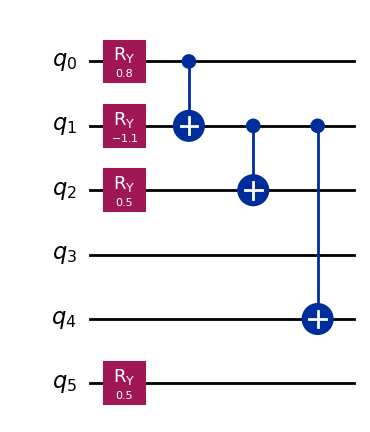

In [16]:
N = 6

qc = QuantumCircuit(N)

qc.ry(0.8, 0)
qc.ry(-1.1, 1)
qc.ry(0.5, 2)
qc.cx(0, 1)
qc.cx(1, 2)
qc.ry(0.5, 5)
qc.cx(1, 4)
qc.draw("mpl")

In [17]:
df_tomo, rho_tomo = extract_real_amplitudes_from_tomography(
    qc,
    shots=50000,
    reference_sign=+1,
    make_physical=True,
    return_rho=True,
)

df_tomo

,basis_index,bitstring,rho_0x_real,rho_xx_real,estimated_amplitude,magnitude_from_diagonal,sign
0,0,000000,0.497017,0.497017,0.704994,0.704994,1
1,1,000001,-0.127840,0.036880,-0.181335,0.192043,-1
2,2,000010,-0.000413,0.003047,-0.000586,0.055203,-1
3,3,000011,0.000143,0.001780,0.000203,0.042195,1
4,4,000100,0.127845,0.034886,0.181342,0.186777,1
...,...,...,...,...,...,...,...
59,59,111011,0.000475,0.000304,0.000674,0.017446,1
60,60,111100,-0.000872,0.000603,-0.001237,0.024565,-1
61,61,111101,0.000227,0.000157,0.000322,0.012522,1
62,62,111110,-0.000069,0.000981,-0.000098,0.031322,-1


## 10. Compare against exact statevector simulation

This is only for debugging in simulation.

On real hardware, the exact statevector is not available.

In [18]:
def exact_real_statevector_amplitudes(state_circuit, reference_sign=+1):
    """
    Exact real amplitudes from statevector simulation.

    This is only for simulation/debugging.
    """
    n = state_circuit.num_qubits

    U = state_circuit.copy()
    U.remove_final_measurements(inplace=True)

    psi = Statevector.from_instruction(U).data

    if np.max(np.abs(np.imag(psi))) > 1e-10:
        print("Warning: the state has non-negligible imaginary amplitudes.")

    amps = np.real(psi)

    if abs(amps[0]) < 1e-12:
        raise ValueError("First amplitude is zero, cannot use it as reference.")

    # Fix global sign convention.
    global_sign = reference_sign * np.sign(amps[0])
    amps = global_sign * amps

    rows = []

    for i, amp in enumerate(amps):
        rows.append(
            {
                "basis_index": i,
                "bitstring": format(i, f"0{n}b"),
                "exact_amplitude": amp,
            }
        )

    return pd.DataFrame(rows)


df_exact = exact_real_statevector_amplitudes(qc, reference_sign=+1)

comparison = df_tomo.merge(
    df_exact,
    on=["basis_index", "bitstring"],
)

comparison[
    [
        "bitstring",
        "estimated_amplitude",
        "exact_amplitude",
        "sign",
    ]
]

,bitstring,estimated_amplitude,exact_amplitude,sign
0,000000,0.704994,0.737164,1
1,000001,-0.181335,-0.191085,-1
2,000010,-0.000586,0.000000,-1
3,000011,0.000203,0.000000,1
4,000100,0.181342,0.188229,1
...,...,...,...,...
59,111011,0.000674,0.000000,1
60,111100,-0.001237,0.000000,-1
61,111101,0.000322,0.000000,1
62,111110,-0.000098,0.000000,-1


## 11. Extract amplitudes from the reconstructed density matrix

In [19]:
amps = amplitudes_from_density_matrix_real_reference(
    rho_tomo,
    n=N,
    reference_sign=+1,
)

amps

array([ 7.04994364e-01, -1.81334757e-01, -5.86143483e-04,  2.03317797e-04,
        1.81341519e-01, -4.60219526e-02,  1.31068416e-03, -3.63795667e-04,
        2.45150829e-03,  1.29685592e-03,  3.79662416e-04,  3.70607826e-04,
       -8.97613011e-04,  3.99297344e-04, -3.47145579e-05,  5.64379156e-04,
        2.05025306e-04,  7.28770544e-04, -1.09042537e-01,  7.61496790e-02,
        6.17991965e-04,  1.68481461e-04, -4.30606467e-01,  2.95212452e-01,
       -2.48388820e-05, -1.74117795e-03, -7.34258277e-04, -6.14277237e-05,
       -2.20370675e-04, -3.93600519e-04, -1.40092071e-03,  3.13826749e-04,
        1.77273551e-01, -4.69451809e-02, -1.69153965e-03,  1.98483362e-03,
        4.50156768e-02, -1.39158407e-02, -4.21157312e-04, -3.63268164e-04,
       -9.32030728e-04, -5.66000843e-04, -1.24741197e-03, -4.48369340e-04,
        8.94042051e-04, -6.36746000e-04, -8.60410069e-04, -1.10562647e-04,
       -4.87896349e-04,  1.46656123e-03, -2.77957821e-02,  1.92814364e-02,
       -1.42386602e-03, -

## 12. Main function usage

For your own circuit `my_circuit`, use:

```python
df_tomo, rho_tomo = extract_real_amplitudes_from_tomography(
    my_circuit,
    shots=50000,
    reference_sign=+1,
    return_rho=True,
)
```

The signed amplitudes are in:

```python
df_tomo[["bitstring", "estimated_amplitude", "sign"]]
```

This assumes

$$
a_{00\cdots0} > 0.
$$